In [ ]:
from mapc_cmab.agents.hierarchical_dqn  import HierarchicalMapcDQNAgent 
from mapc_cmab.agents.mapc_cmab_agent_factory import MapcDQNAgentFactory
from mapc_cmab.envs.scenario_impl import small_office_scenario 
import jax 
import jax.numpy as jnp 
from tqdm import tqdm 


In [ ]:
d_ap = 10
d_sta = 2
scenario = small_office_scenario(d_ap=d_ap, d_sta=d_sta)

{'str_repr': 'static_small_office_10_2', 'CCA_THRESHOLD': -82.0, 'DEFAULT_CHANNEL_WIDTH': 20, 'associations': {0: [4, 5, 6, 7], 1: [8, 9, 10, 11], 2: [12, 13, 14, 15], 3: [16, 17, 18, 19]}, 'pos': Array([[ 0.       ,  0.       ],
       [10.       ,  0.       ],
       [10.       , 10.       ],
       [ 0.       , 10.       ],
       [-1.4142135, -1.4142135],
       [ 1.4142135, -1.4142135],
       [ 1.4142135,  1.4142135],
       [-1.4142135,  1.4142135],
       [ 8.585787 , -1.4142135],
       [11.414213 , -1.4142135],
       [11.414213 ,  1.4142135],
       [ 8.585787 ,  1.4142135],
       [ 8.585787 ,  8.585787 ],
       [11.414213 ,  8.585787 ],
       [11.414213 , 11.414213 ],
       [ 8.585787 , 11.414213 ],
       [-1.4142135,  8.585787 ],
       [ 1.4142135,  8.585787 ],
       [ 1.4142135, 11.414213 ],
       [-1.4142135, 11.414213 ]], dtype=float32), 'walls_pos': Array([[-5.,  5., 15.,  5.],
       [ 5.,  5.,  5., 15.]], dtype=float32), 'walls': Array([[0., 0., 1., 1., 0., 0

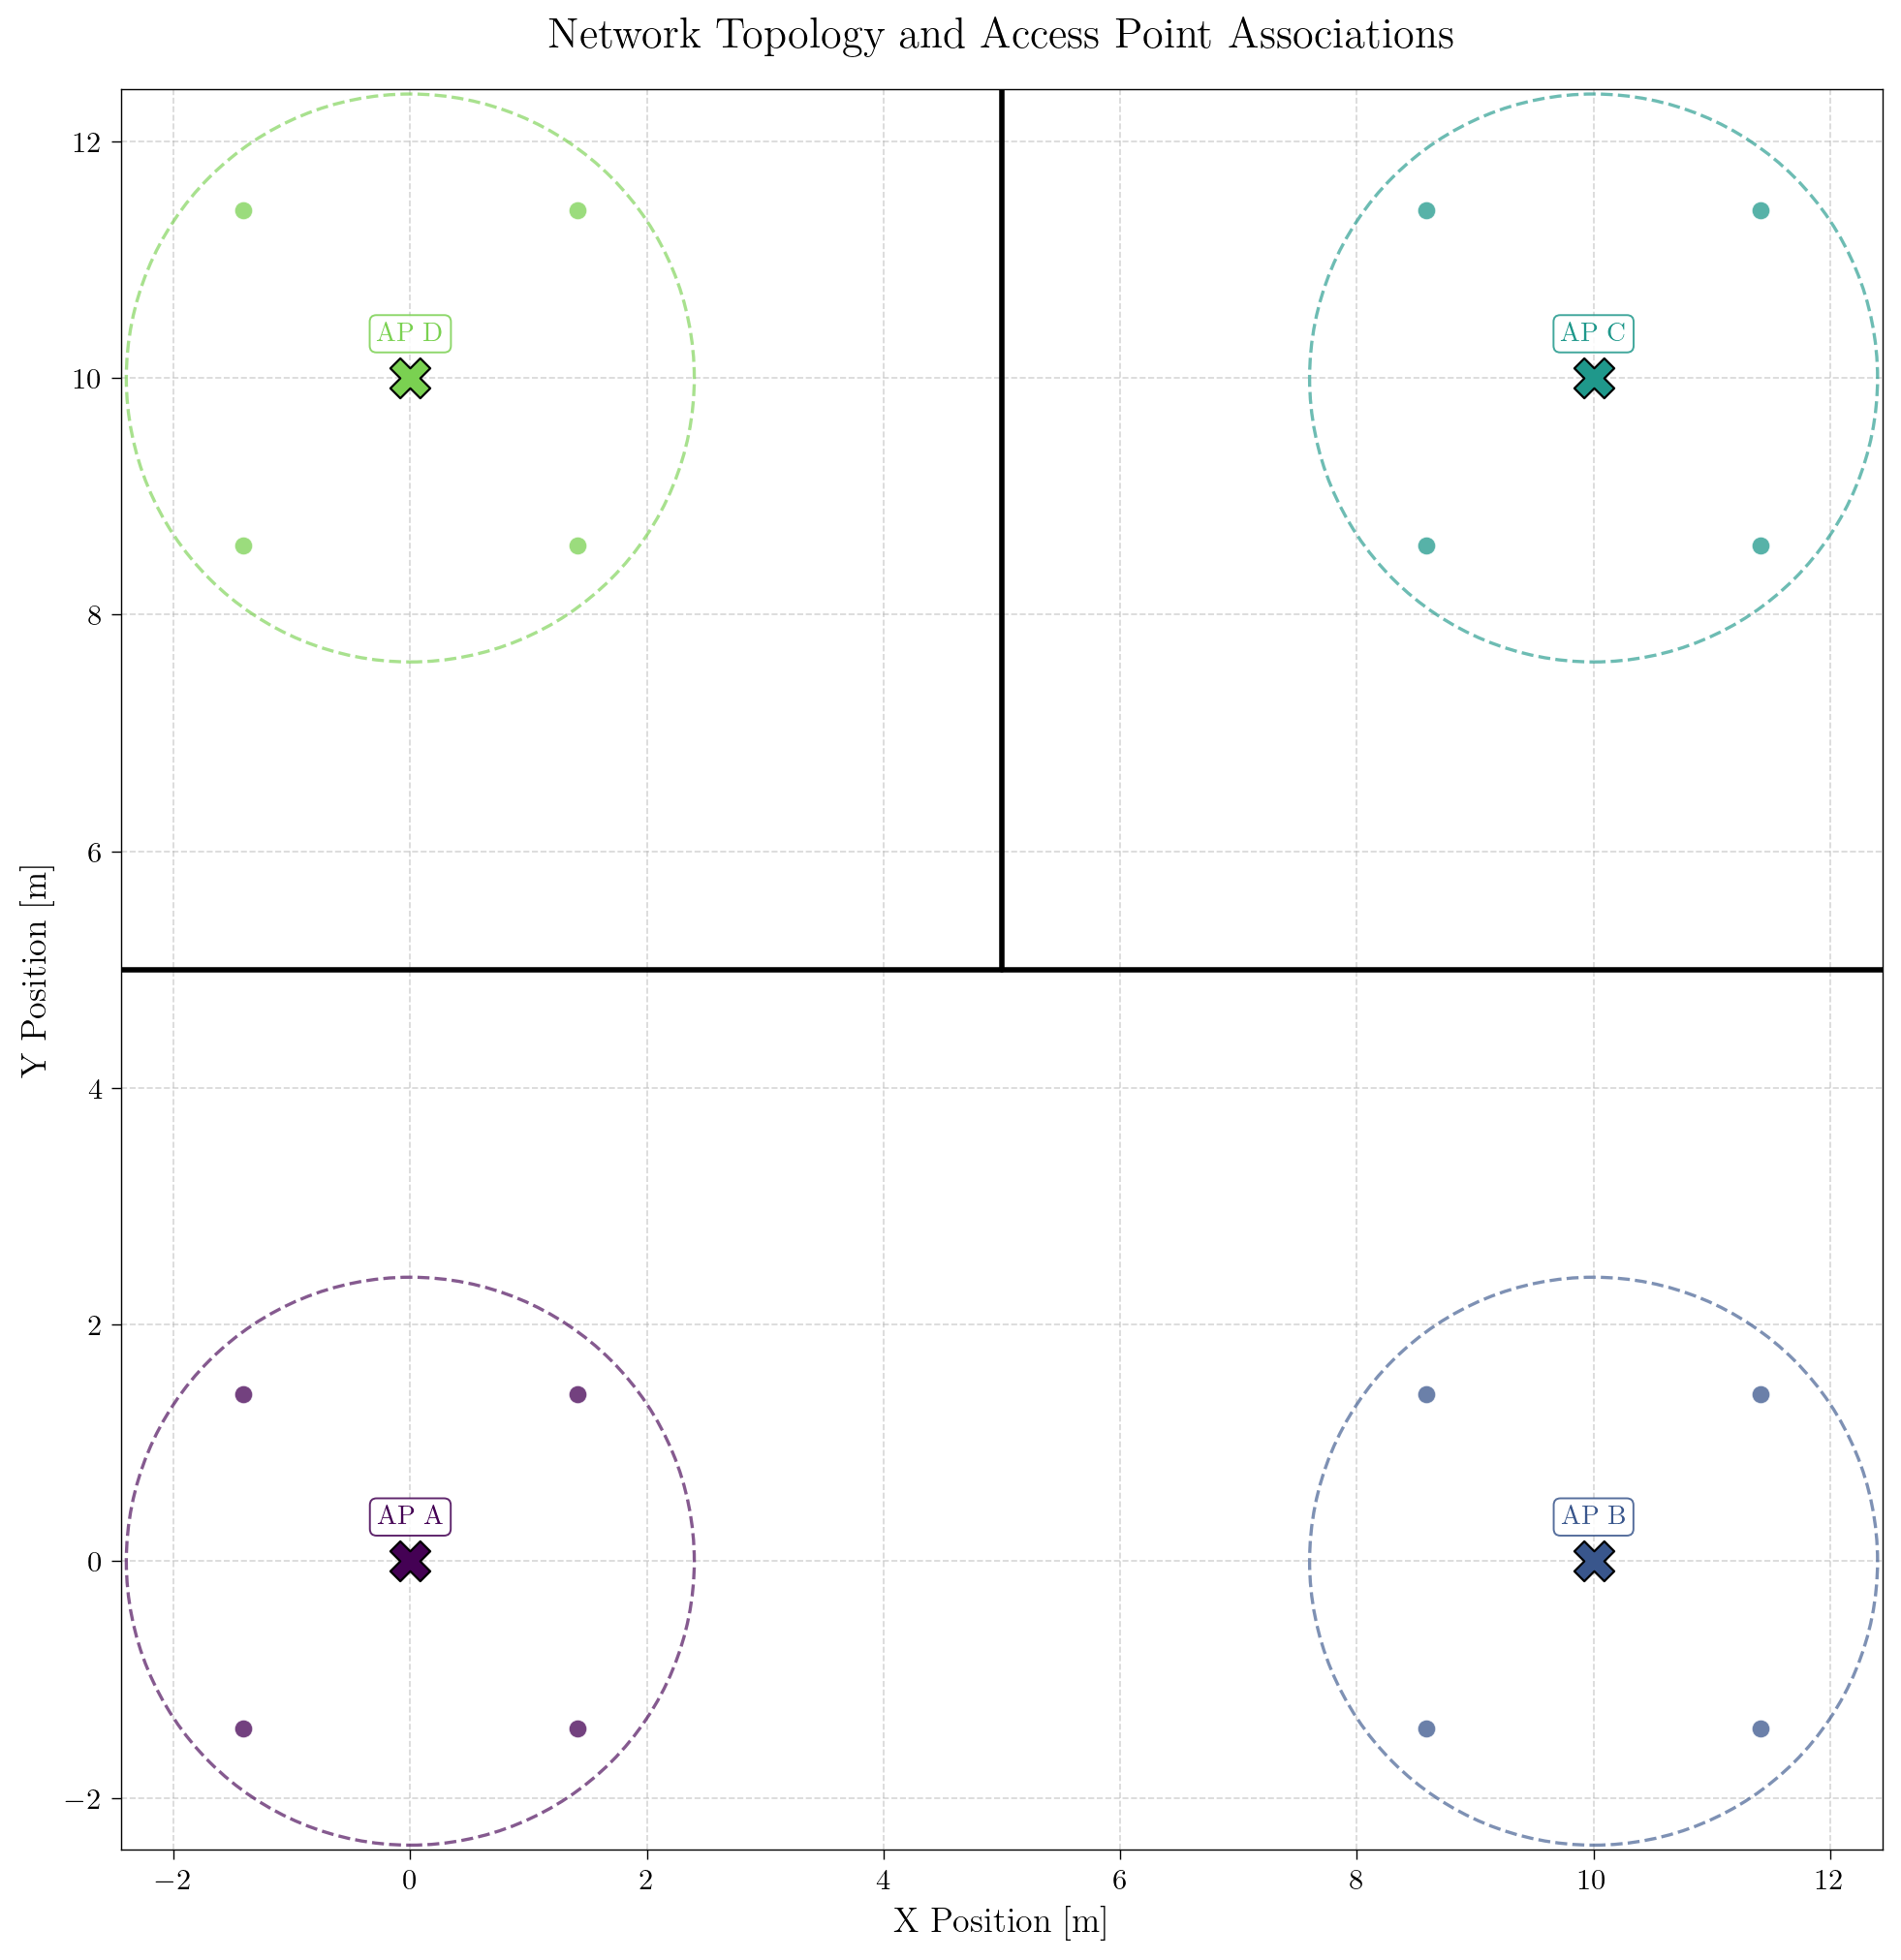

In [ ]:
print(scenario.__dict__)
scenario.plot_rs()

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import os
import numpy as np
import jax
import jax.numpy as jnp
from tqdm.auto import tqdm

# Set a local directory for the persistent compilation cache (FIXED NAME)
jax.config.update("jax_compilation_cache_dir", "./jax_cache")

# Enable all extra XLA caching features ("all")
jax.config.update("jax_persistent_cache_enable_xla_caches", "all")

agent_factory = MapcDQNAgentFactory(
    associations=scenario.associations,
    agent_params_lvl1=None, 
    agent_params_lvl2=None, 
    agent_params_lvl3=None, 
    agent_params_lvl4=None, 
    n_tx_power_levels=4, 
    n_links=3, 
    seed=42
)


def run_agent_thread(
    run_number: int,
    key: jax.Array,
    n_steps: int,
):

    # Independent agent
    agent = (
        agent_factory.create_hierarchical_DQN_cmapc_agent()
    )

    throughputs = np.zeros(
        n_steps,
        dtype=np.float32
    )

    previous_throughput = 0.0

    for step in tqdm(range(1, n_steps), desc=f"run number: {run_number}"):

        key, run_key = jax.random.split(key)

        link_ap_sta = agent.sample(
            reward=previous_throughput
        )

        data_rate, reward = scenario(
            run_key,
            link_ap_sta,
        )

        data_rate = float(data_rate)

        throughputs[step] = data_rate
        previous_throughput = data_rate

    return run_number, throughputs

def compute_multiple_runs_threaded(
    n_runs: int,
    key: jax.Array,
    n_steps: int,
    max_workers: int | None = None,
):

    if max_workers is None:
        max_workers = min(
            n_runs,
            os.cpu_count() or 1
        )

    run_keys = jax.random.split(
        key,
        n_runs
    )

    results = [None] * n_runs

    with ThreadPoolExecutor(
        max_workers=max_workers
    ) as executor:

        futures = [
            executor.submit(
                run_agent_thread,
                run_number,
                run_keys[run_number],
                n_steps,
            )
            for run_number in range(n_runs)
        ]

        for future in tqdm(
            as_completed(futures),
            total=n_runs,
            desc="Running repetitions",
        ):

            run_number, result = future.result()

            results[run_number] = result

    return jnp.asarray(
        np.stack(results)
    )

# ============================================================
# RUN
# ============================================================

total_steps = 5000
n_reps = 10

key = jax.random.PRNGKey(42)

throughputs = compute_multiple_runs_threaded(
    n_runs=n_reps,
    key=key,
    n_steps=5000,
    max_workers=10,
)

run number: 3:   0%|          | 0/4999 [00:00<?, ?it/s]

run number: 0:   0%|          | 0/4999 [00:00<?, ?it/s]

run number: 2:   0%|          | 0/4999 [00:00<?, ?it/s]

run number: 7:   0%|          | 0/4999 [00:00<?, ?it/s]

run number: 6:   0%|          | 0/4999 [00:00<?, ?it/s]

...

run number: 5:   0%|          | 0/4999 [00:00<?, ?it/s]

run number: 4:   0%|          | 0/4999 [00:00<?, ?it/s]

run number: 1:   0%|          | 0/4999 [00:00<?, ?it/s]

Running repetitions:   0%|          | 0/10 [00:00<?, ?it/s]

run number: 9:   0%|          | 0/4999 [00:00<?, ?it/s]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from pathlib import Path


def analyze_and_plot_throughputs(
    throughputs,
    window_size: int = 100,
    step_duration: float = 0.005,
    confidence: float = 0.99,
    title: str = "Average Throughput Over Time",
    label: str = "Average throughput",
    output_dir: str = "./results",
    filename: str = "throughput_results",
    save: bool = True,
    show: bool = True,
):
    """
    Analyze throughput measurements from multiple independent runs,
    compute windowed averages and Student-t confidence intervals,
    plot the results, and optionally save them.

    Parameters
    ----------
    throughputs : array-like
        Throughput measurements with shape:

            (n_runs, total_steps)

        Each row represents one independent experiment/run.

    window_size : int, default=100
        Number of consecutive simulation steps to average into
        one plotted measurement.

    step_duration : float, default=0.005
        Duration represented by one simulation step, in seconds.

    confidence : float, default=0.99
        Confidence level for the Student-t confidence interval.

    title : str
        Plot title.

    label : str
        Label for the mean throughput curve.

    output_dir : str
        Directory where results will be saved.

    filename : str
        Base filename without extension.

    save : bool, default=True
        Whether to save the figure and processed statistics.

    show : bool, default=True
        Whether to display the plot.

    Returns
    -------
    results : dict
        Dictionary containing:
            - windowed_throughputs
            - time
            - mean
            - std
            - standard_error
            - ci_low
            - ci_high
    """

    # =========================================================
    # Convert to NumPy
    # =========================================================
    throughputs = np.asarray(throughputs)

    # =========================================================
    # Validate input
    # =========================================================
    if throughputs.ndim != 2:
        raise ValueError(
            "throughputs must have shape "
            "(n_runs, total_steps)."
        )

    n_runs, total_steps = throughputs.shape

    if n_runs < 2:
        raise ValueError(
            "At least 2 independent runs are required "
            "to compute a confidence interval."
        )

    if total_steps % window_size != 0:
        raise ValueError(
            f"total_steps ({total_steps}) must be exactly "
            f"divisible by window_size ({window_size}).\n"
            "No data will be silently sliced or discarded."
        )

    if not 0 < confidence < 1:
        raise ValueError(
            "confidence must be between 0 and 1."
        )

    # =========================================================
    # Windowed averaging
    #
    # (n_runs, total_steps)
    #
    #        ↓ reshape
    #
    # (n_runs, n_windows, window_size)
    #
    #        ↓ mean
    #
    # (n_runs, n_windows)
    # =========================================================
    n_windows = total_steps // window_size

    windowed_throughputs = (
        throughputs
        .reshape(
            n_runs,
            n_windows,
            window_size,
        )
        .mean(axis=-1)
    )

    # =========================================================
    # Statistics across independent runs
    # =========================================================
    mean_ts = windowed_throughputs.mean(axis=0)

    # Sample standard deviation
    std_ts = windowed_throughputs.std(
        axis=0,
        ddof=1,
    )

    standard_error = (
        std_ts /
        np.sqrt(n_runs)
    )

    # =========================================================
    # Student-t confidence interval
    # =========================================================
    alpha = 1 - confidence

    critical_value = t.ppf(
        1 - alpha / 2,
        df=n_runs - 1,
    )

    margin_of_error = (
        critical_value *
        standard_error
    )

    ci_low = (
        mean_ts -
        margin_of_error
    )

    ci_high = (
        mean_ts +
        margin_of_error
    )

    # =========================================================
    # Time axis
    # =========================================================
    window_duration = (
        window_size *
        step_duration
    )

    time = (
        np.arange(n_windows + 1) *
        window_duration
    )

    # Add initial zero to match your plotting convention
    mean_plot = np.concatenate(
        [[0.0], mean_ts]
    )

    ci_low_plot = np.concatenate(
        [[0.0], ci_low]
    )

    ci_high_plot = np.concatenate(
        [[0.0], ci_high]
    )

    # =========================================================
    # Create figure
    # =========================================================
    fig, ax = plt.subplots(
        figsize=(11, 7),
        dpi=600,
    )

    # Mean throughput
    ax.plot(
        time,
        mean_plot,
        marker="o",
        markersize=4.5,
        linewidth=2.4,
        label=label,
    )

    # Confidence interval
    ax.fill_between(
        time,
        ci_low_plot,
        ci_high_plot,
        alpha=0.16,
        label=f"{int(confidence * 100)}% CI",
        interpolate=True,
    )

    # =========================================================
    # Labels
    # =========================================================
    ax.set_title(
        title,
        fontsize=19,
        fontweight="normal",
        pad=16,
    )

    ax.set_xlabel(
        "Time (s)",
        fontsize=18,
        fontweight="normal",
        labelpad=12,
    )

    ax.set_ylabel(
        "Throughput [Mb/s]",
        fontsize=18,
        fontweight="normal",
        labelpad=12,
    )

    # =========================================================
    # Tick formatting
    # =========================================================
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=16,
        width=1.3,
        length=6,
        colors="black",
        pad=7,
    )

    # =========================================================
    # Grid
    # =========================================================
    ax.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.8,
        alpha=0.30,
    )

    # =========================================================
    # Spines
    # =========================================================
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color("black")

    # =========================================================
    # Legend
    # =========================================================
    ax.legend(
        fontsize=13,
        frameon=True,
        fancybox=False,
        framealpha=0.95,
        edgecolor="black",
        loc="best",
    )

    fig.tight_layout()

    # =========================================================
    # Save results
    # =========================================================
    if save:

        output_path = Path(output_dir)
        output_path.mkdir(
            parents=True,
            exist_ok=True,
        )

        # Save figure
        figure_path = (
            output_path /
            f"{filename}.png"
        )

        fig.savefig(
            figure_path,
            dpi=600,
            bbox_inches="tight",
        )

        # Save processed numerical results
        data_path = (
            output_path /
            f"{filename}.npz"
        )

        np.savez(
            data_path,
            raw_throughputs=throughputs,
            windowed_throughputs=windowed_throughputs,
            time=time,
            mean=mean_plot,
            std=np.concatenate([[0.0], std_ts]),
            standard_error=np.concatenate(
                [[0.0], standard_error]
            ),
            ci_low=ci_low_plot,
            ci_high=ci_high_plot,
            confidence=confidence,
            critical_value=critical_value,
            n_runs=n_runs,
            total_steps=total_steps,
            window_size=window_size,
            step_duration=step_duration,
        )

        print(f"Figure saved to:\n{figure_path}")
        print(f"Statistics saved to:\n{data_path}")

    # =========================================================
    # Show plot
    # =========================================================
    if show:
        plt.show()

    else:
        plt.close(fig)

    # =========================================================
    # Return everything useful
    # =========================================================
    return {
        "windowed_throughputs": windowed_throughputs,
        "time": time,
        "mean": mean_plot,
        "std": np.concatenate([[0.0], std_ts]),
        "standard_error": np.concatenate(
            [[0.0], standard_error]
        ),
        "ci_low": ci_low_plot,
        "ci_high": ci_high_plot,
        "confidence": confidence,
        "critical_value": critical_value,
        "n_runs": n_runs,
    }

Figure saved to:
results\d_10_with_ss.png
Statistics saved to:
results\d_10_with_ss.npz


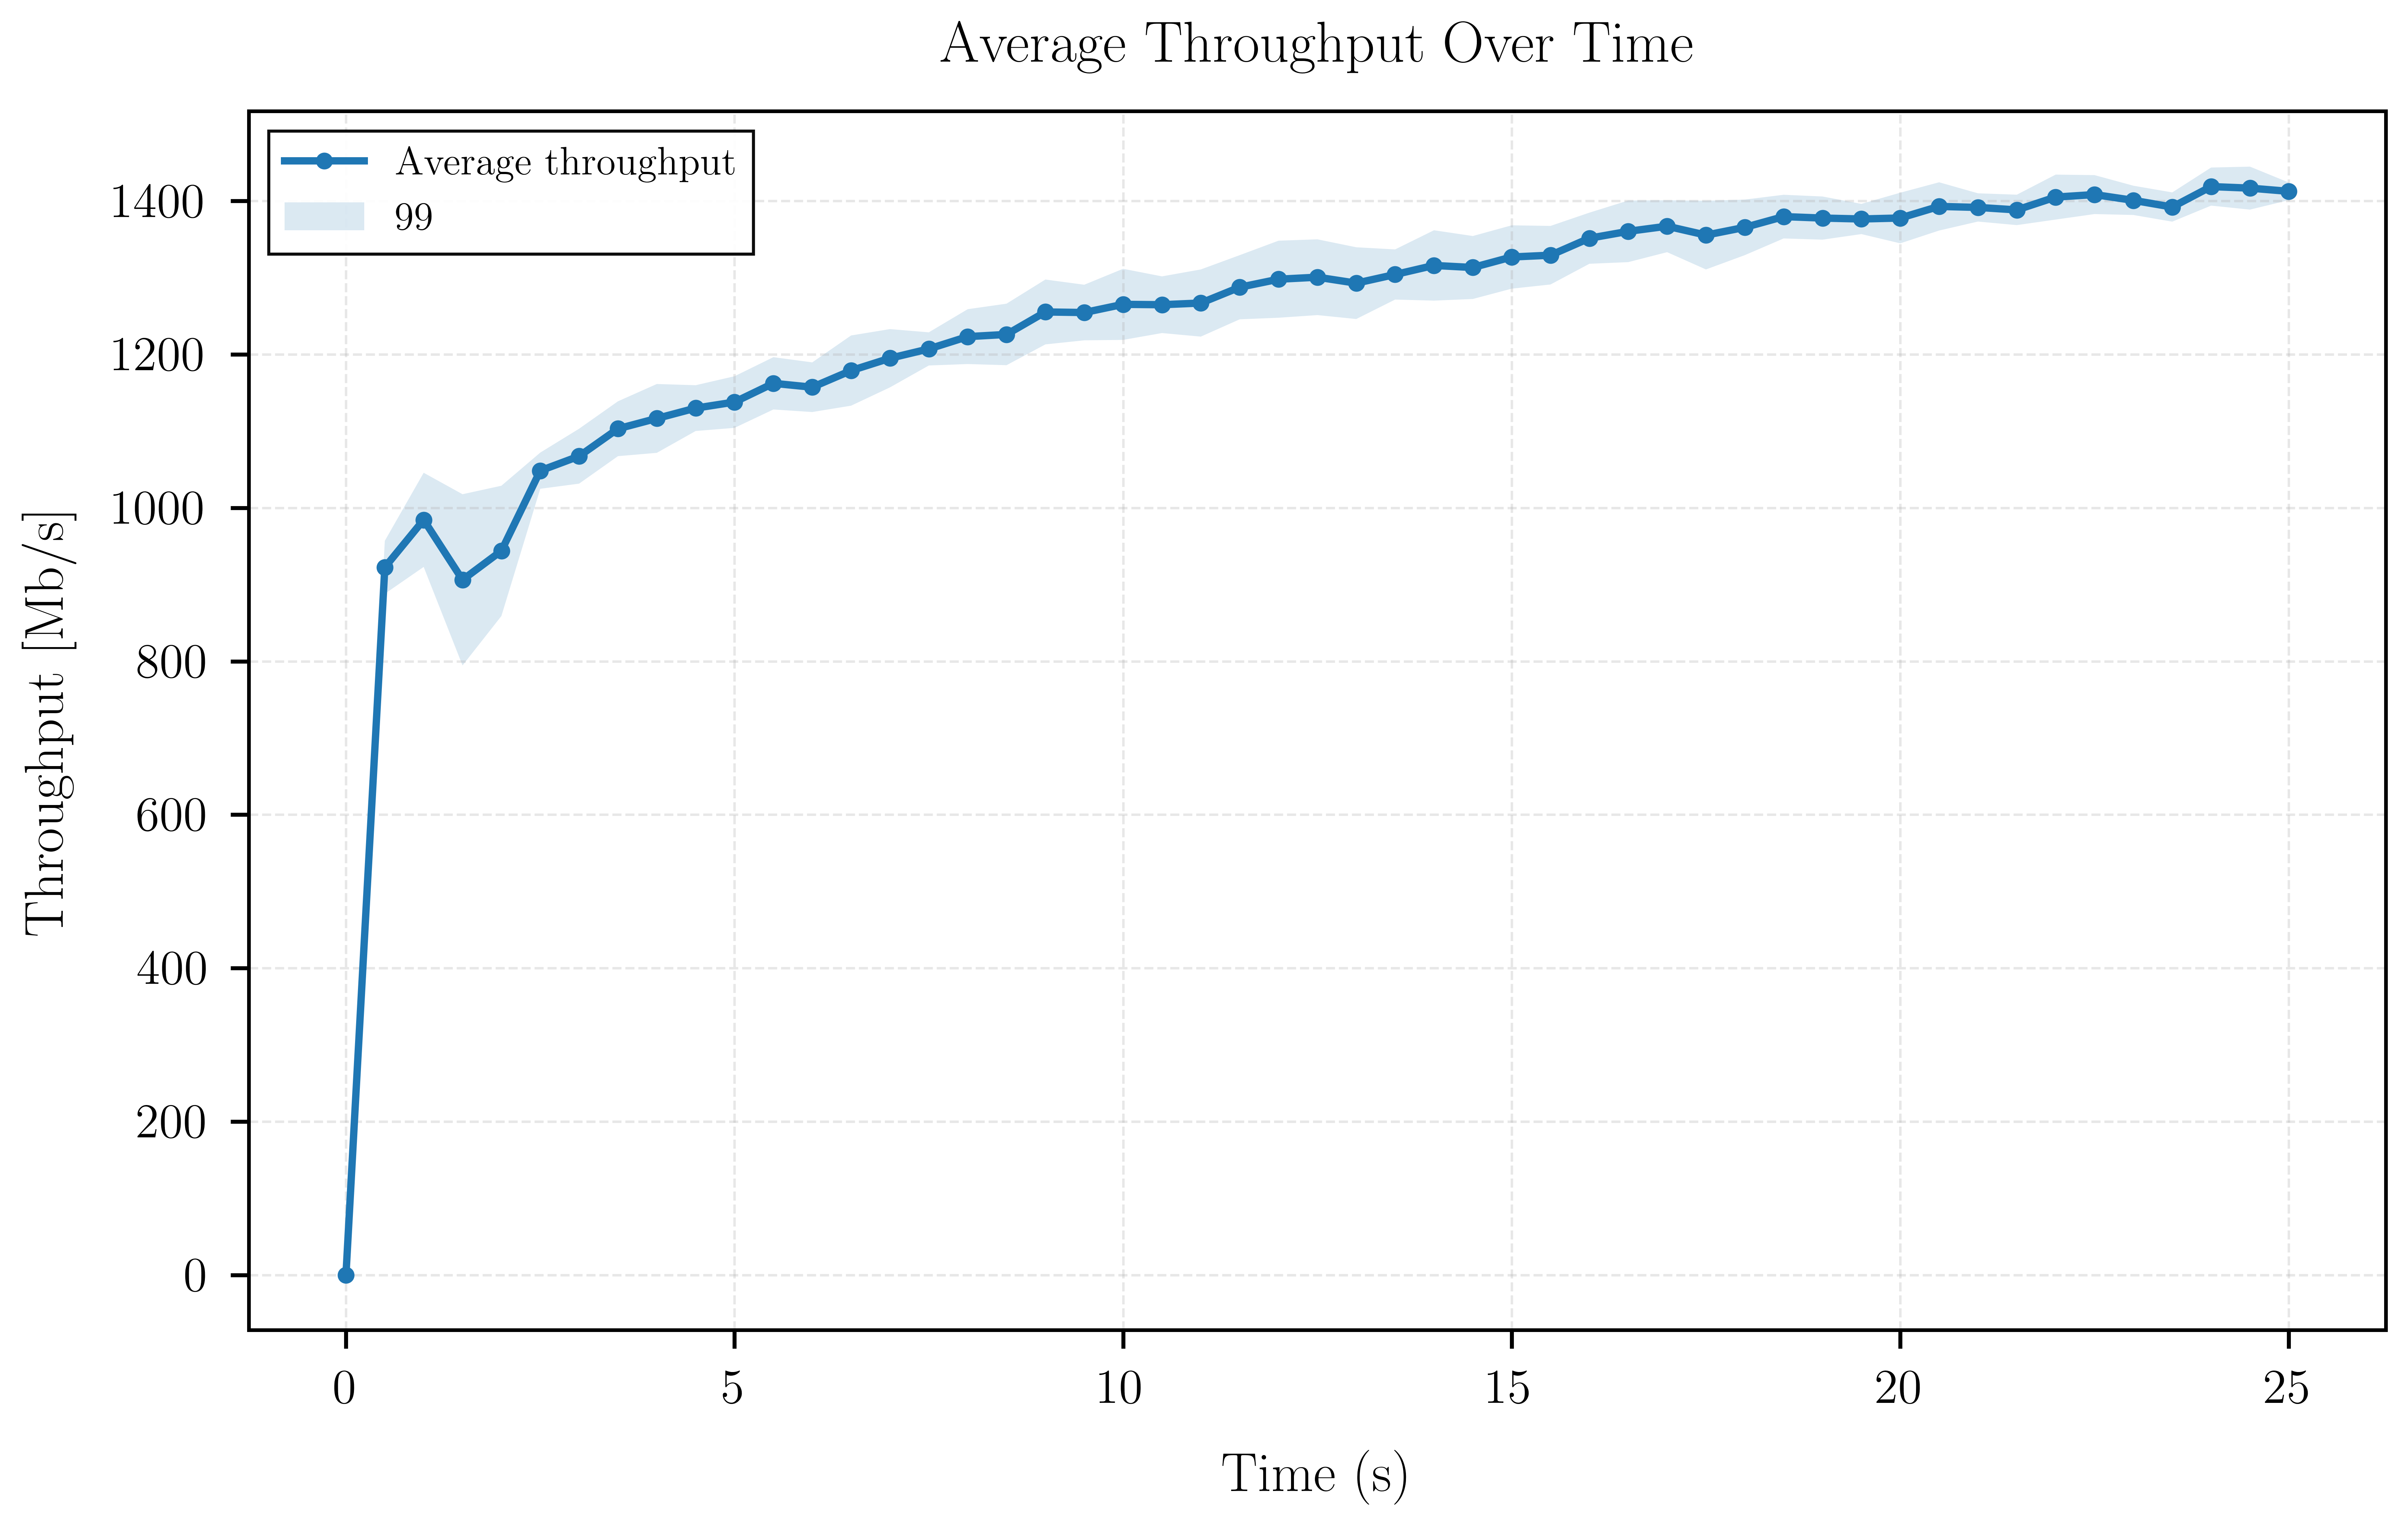

{'windowed_throughputs': array([[ 932.10065, 1059.5187 ,  991.37854, 1002.18823, 1096.9583 ,
         1059.1466 , 1068.0087 , 1176.8927 , 1168.3151 , 1176.9585 ,
         1169.5186 , 1158.9496 , 1217.6367 , 1227.0022 , 1171.6193 ,
         1198.9276 , 1189.7593 , 1245.8206 , 1268.5339 , 1282.5164 ,
         1247.1553 , 1280.4813 , 1299.9999 , 1351.3566 , 1297.7025 ,
         1270.722  , 1294.6171 , 1309.8905 , 1299.4312 , 1353.8292 ,
         1350.9847 , 1370.8096 , 1349.9343 , 1355.7987 , 1380.8972 ,
         1375.1859 , 1356.9146 , 1352.9321 , 1362.7133 , 1374.9893 ,
         1379.6062 , 1401.9038 , 1397.571  , 1416.8053 , 1428.8618 ,
         1392.4728 , 1381.0066 , 1397.2211 , 1408.6871 , 1392.0348 ],
        [ 930.3282 ,  993.12915,  789.7374 ,  926.6083 , 1046.9802 ,
         1110.7657 , 1086.3894 , 1029.1902 , 1135.2953 , 1152.6914 ,
         1146.9584 , 1167.943  , 1216.477  , 1217.396  , 1219.1246 ,
         1253.3042 , 1235.0764 , 1278.9059 , 1266.302  , 1305.9738 ,
         

In [ ]:
analyze_and_plot_throughputs(throughputs, filename="./d_10_with_ss_parallel_runs")